In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/processed/hdfc_top100_nav_clean.csv")

df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date')

df.head()

,date,nav
3104,2013-11-18,13.0894
3103,2013-11-19,13.1068
3102,2013-11-20,12.9549
3101,2013-11-21,12.7957
3100,2013-11-22,12.7775


In [3]:
df['daily_return'] = df['nav'].pct_change()

df.head()

,date,nav,daily_return
3104,2013-11-18,13.0894,NaN
3103,2013-11-19,13.1068,0.001329
3102,2013-11-20,12.9549,-0.011589
3101,2013-11-21,12.7957,-0.012289
3100,2013-11-22,12.7775,-0.001422


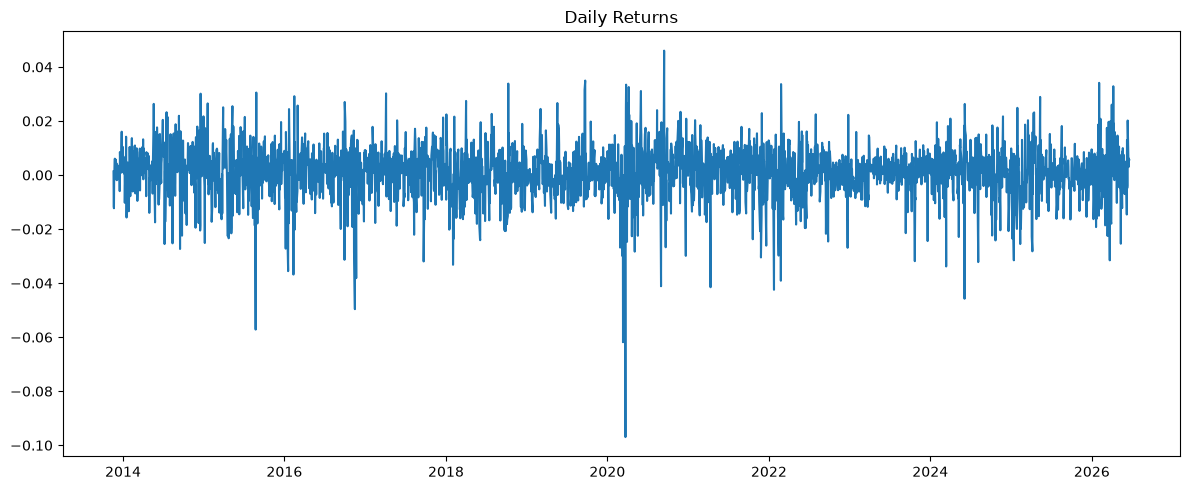

In [4]:
plt.figure(figsize=(12,5))
plt.plot(df['date'], df['daily_return'])
plt.title("Daily Returns")
plt.tight_layout()
plt.show()

In [5]:
start_nav = df['nav'].iloc[0]
end_nav = df['nav'].iloc[-1]

years = (
    df['date'].iloc[-1] -
    df['date'].iloc[0]
).days / 365

cagr = (end_nav / start_nav)**(1/years) - 1

print("CAGR:", round(cagr*100,2), "%")

CAGR: 24.28 %


In [6]:
rf = 0.065

mean_return = df['daily_return'].mean() * 252
std_return = df['daily_return'].std() * np.sqrt(252)

sharpe = (mean_return - rf) / std_return

print("Sharpe Ratio:", round(sharpe,2))

Sharpe Ratio: 1.11


In [7]:
df['running_max'] = df['nav'].cummax()

df['drawdown'] = (
    df['nav'] /
    df['running_max']
) - 1

max_drawdown = df['drawdown'].min()

print("Maximum Drawdown:", round(max_drawdown*100,2), "%")

Maximum Drawdown: -40.26 %


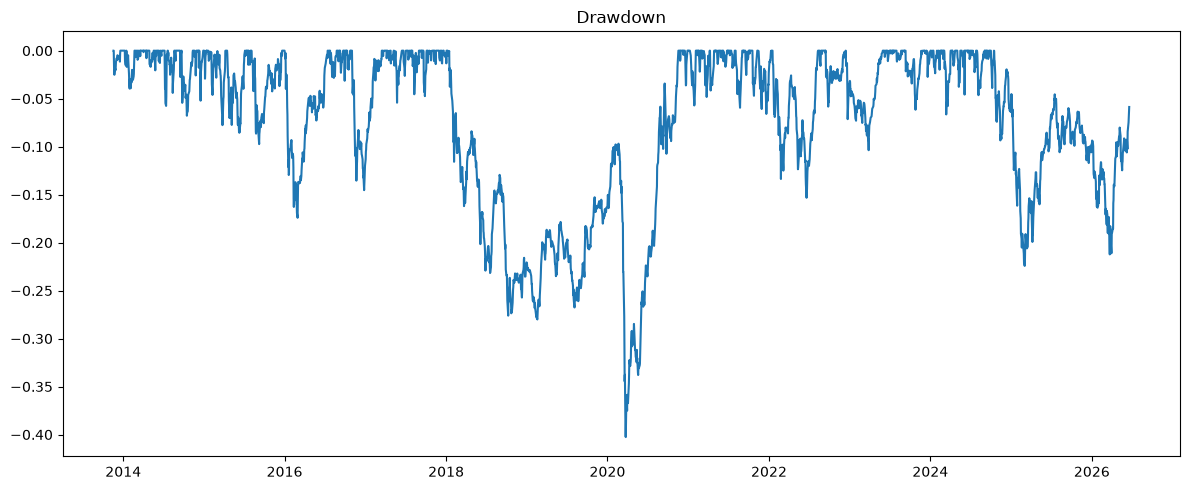

In [8]:
plt.figure(figsize=(12,5))
plt.plot(df['date'], df['drawdown'])
plt.title("Drawdown")
plt.tight_layout()
plt.show()

In [9]:
scorecard = pd.DataFrame({
    'Metric':[
        'CAGR',
        'Sharpe Ratio',
        'Maximum Drawdown'
    ],
    'Value':[
        cagr,
        sharpe,
        max_drawdown
    ]
})

scorecard.to_csv(
    "../reports/fund_scorecard.csv",
    index=False
)

scorecard

,Metric,Value
0,CAGR,0.242781
1,Sharpe Ratio,1.110988
2,Maximum Drawdown,-0.402601


In [10]:
scorecard = pd.DataFrame({
    'Metric':[
        'CAGR',
        'Sharpe Ratio',
        'Maximum Drawdown'
    ],
    'Value':[
        cagr,
        sharpe,
        max_drawdown
    ]
})

scorecard.to_csv(
    "../reports/fund_scorecard.csv",
    index=False
)

scorecard

,Metric,Value
0,CAGR,0.242781
1,Sharpe Ratio,1.110988
2,Maximum Drawdown,-0.402601


In [11]:
start_nav = df['nav'].iloc[0]
end_nav = df['nav'].iloc[-1]

years = (df['date'].iloc[-1] - df['date'].iloc[0]).days / 365

cagr = (end_nav / start_nav)**(1 / years) - 1

print(f"CAGR: {cagr*100:.2f}%")

CAGR: 24.28%


In [12]:
import numpy as np

rf = 0.065  # 6.5%

annual_return = df['daily_return'].mean() * 252
annual_volatility = df['daily_return'].std() * np.sqrt(252)

sharpe = (annual_return - rf) / annual_volatility

print(f"Sharpe Ratio: {sharpe:.2f}")

Sharpe Ratio: 1.11


In [13]:
downside = df[df['daily_return'] < 0]['daily_return']

downside_std = downside.std() * np.sqrt(252)

sortino = (annual_return - rf) / downside_std

print(f"Sortino Ratio: {sortino:.2f}")

Sortino Ratio: 1.34


In [14]:
df['running_max'] = df['nav'].cummax()

df['drawdown'] = df['nav'] / df['running_max'] - 1

max_drawdown = df['drawdown'].min()

print(f"Maximum Drawdown: {max_drawdown*100:.2f}%")

Maximum Drawdown: -40.26%


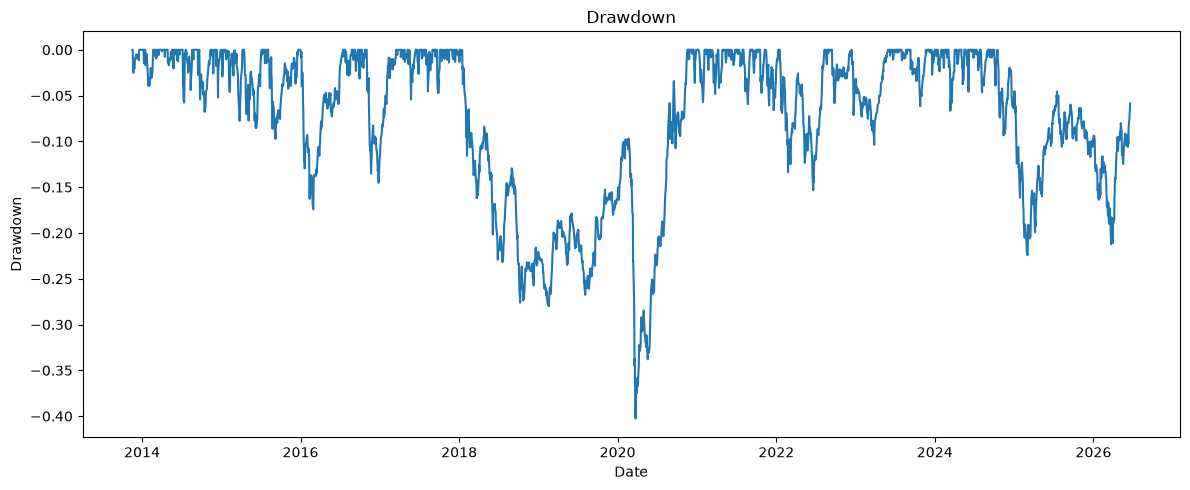

In [15]:
plt.figure(figsize=(12,5))
plt.plot(df['date'], df['drawdown'])
plt.title('Drawdown')
plt.xlabel('Date')
plt.ylabel('Drawdown')
plt.tight_layout()

plt.savefig('../charts/drawdown.png')
plt.show()

In [16]:
scorecard = pd.DataFrame({
    'Metric': [
        'CAGR',
        'Sharpe Ratio',
        'Sortino Ratio',
        'Maximum Drawdown'
    ],
    'Value': [
        cagr,
        sharpe,
        sortino,
        max_drawdown
    ]
})

scorecard.to_csv(
    '../reports/fund_scorecard.csv',
    index=False
)

scorecard

,Metric,Value
0,CAGR,0.242781
1,Sharpe Ratio,1.110988
2,Sortino Ratio,1.344972
3,Maximum Drawdown,-0.402601


In [17]:
nifty = pd.read_csv("../data/processed/nifty50_clean.csv")

nifty = nifty.iloc[1:].copy()

nifty.rename(columns={
    "Price": "date",
    "Close": "price"
}, inplace=True)

nifty["date"] = pd.to_datetime(nifty["date"])
nifty["price"] = pd.to_numeric(nifty["price"])

nifty["benchmark_return"] = nifty["price"].pct_change()

nifty.head()

,date,price,High,Low,Open,Volume,benchmark_return
1,2022-01-03,17625.699219,17646.650390625,17383.30078125,17387.150390625,200500,NaN
2,2022-01-04,17805.250000,17827.599609375,17593.55078125,17681.400390625,247400,0.010187
3,2022-01-05,17925.250000,17944.69921875,17748.849609375,17820.099609375,251500,0.006740
4,2022-01-06,17745.900391,17797.94921875,17655.55078125,17768.5,236500,-0.010005
5,2022-01-07,17812.699219,17905.0,17704.55078125,17797.599609375,239300,0.003764


In [18]:
nifty = pd.read_csv("../data/processed/nifty50_clean.csv")

nifty = nifty.iloc[1:].copy()

nifty.rename(columns={
    "Price": "date",
    "Close": "price"
}, inplace=True)

nifty["date"] = pd.to_datetime(nifty["date"])
nifty["price"] = pd.to_numeric(nifty["price"])

nifty["benchmark_return"] = nifty["price"].pct_change()

nifty.head()

,date,price,High,Low,Open,Volume,benchmark_return
1,2022-01-03,17625.699219,17646.650390625,17383.30078125,17387.150390625,200500,NaN
2,2022-01-04,17805.250000,17827.599609375,17593.55078125,17681.400390625,247400,0.010187
3,2022-01-05,17925.250000,17944.69921875,17748.849609375,17820.099609375,251500,0.006740
4,2022-01-06,17745.900391,17797.94921875,17655.55078125,17768.5,236500,-0.010005
5,2022-01-07,17812.699219,17905.0,17704.55078125,17797.599609375,239300,0.003764


In [19]:
merged = pd.merge(
    df[['date', 'daily_return']],
    nifty[['date', 'benchmark_return']],
    on='date'
)

merged.dropna(inplace=True)

merged.head()

,date,daily_return,benchmark_return
1,2022-01-04,0.001394,0.010187
2,2022-01-05,-0.001261,0.006740
3,2022-01-06,0.001978,-0.010005
4,2022-01-07,-0.000171,0.003764
5,2022-01-10,0.010175,0.010700


In [20]:
cov = merged['daily_return'].cov(
    merged['benchmark_return']
)

var = merged['benchmark_return'].var()

beta = cov / var

alpha = (
    merged['daily_return'].mean()
    - beta * merged['benchmark_return'].mean()
) * 252

print("Alpha:", alpha)
print("Beta:", beta)

Alpha: 0.08063566228511614
Beta: 0.689926097490576


In [21]:
alpha_beta = pd.DataFrame({
    "Metric": ["Alpha", "Beta"],
    "Value": [alpha, beta]
})

alpha_beta.to_csv(
    "../reports/alpha_beta.csv",
    index=False
)

alpha_beta

,Metric,Value
0,Alpha,0.080636
1,Beta,0.689926


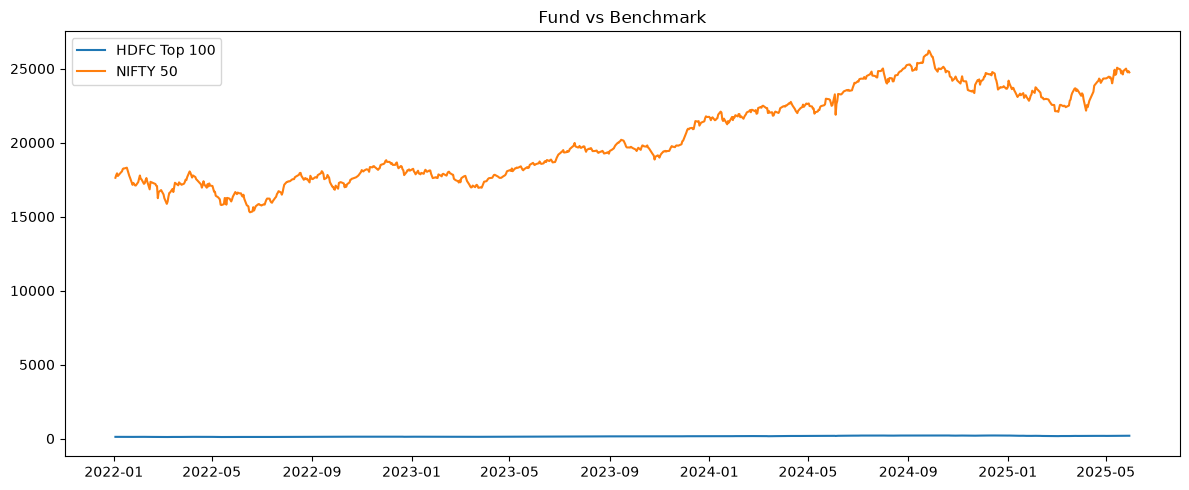

In [22]:
comparison = pd.merge(
    df[['date', 'nav']],
    nifty[['date', 'price']],
    on='date'
)

comparison.rename(columns={
    'nav': 'Fund_NAV',
    'price': 'NIFTY50'
}, inplace=True)

plt.figure(figsize=(12,5))

plt.plot(
    comparison['date'],
    comparison['Fund_NAV'],
    label='HDFC Top 100'
)

plt.plot(
    comparison['date'],
    comparison['NIFTY50'],
    label='NIFTY 50'
)

plt.legend()
plt.title('Fund vs Benchmark')
plt.tight_layout()

plt.savefig("../charts/benchmark_comparison.png")
plt.show()